In [1]:

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score

drive.mount("/content/drive")

SEED = 42
rng = np.random.default_rng(SEED)


Mounted at /content/drive


In [4]:

canonical_df = pd.read_pickle(
    "/content/drive/MyDrive/router_project_canonical.pkl"
)

splits = np.load(
    "/content/drive/MyDrive/router_split_indices.npz"
)

distilbert_val_pred = np.load(
    "/content/drive/MyDrive/distilbert_val_predictions.npy"
)

distilbert_test_pred = np.load(
    "/content/drive/MyDrive/distilbert_test_predictions.npy"
)

distilbert_test_choices = np.load(
    "/content/drive/MyDrive/distilbert_test_choices.npy"
)

FINAL_THRESHOLD = float(
    np.load(
        "/content/drive/MyDrive/distilbert_final_threshold.npy"
    )[0]
)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
test_idx = splits["test_idx"]

print("Canonical:", canonical_df.shape)
print("Train / Val / Test:", len(train_idx), len(val_idx), len(test_idx))
print("Frozen DistilBERT threshold:", FINAL_THRESHOLD)
print("Val predictions:", distilbert_val_pred.shape)
print("Test predictions:", distilbert_test_pred.shape)
print("Saved test choices:", distilbert_test_choices.shape)


Canonical: (22962, 26)
Train / Val / Test: 18369 2296 2297
Frozen DistilBERT threshold: 0.94
Val predictions: (2296, 11)
Test predictions: (2297, 11)
Saved test choices: (2297,)


In [5]:

MODEL_COLS = [
    "WizardLM/WizardLM-13B-V1.2",
    "claude-instant-v1",
    "claude-v1",
    "claude-v2",
    "gpt-3.5-turbo-1106",
    "gpt-4-1106-preview",
    "meta/code-llama-instruct-34b-chat",
    "meta/llama-2-70b-chat",
    "mistralai/mistral-7b-chat",
    "mistralai/mixtral-8x7b-chat",
    "zero-one-ai/Yi-34B-Chat"
]

X = canonical_df[
    ["sample_id", "prompt", "domain", "eval_name"]
].copy()

Y = pd.DataFrame({
    model: canonical_df[f"{model}|performance"]
    for model in MODEL_COLS
})

C = pd.DataFrame({
    model: canonical_df[f"{model}|cost"]
    for model in MODEL_COLS
})

X_train = X.iloc[train_idx].reset_index(drop=True)
X_val = X.iloc[val_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)

Y_train = Y.iloc[train_idx].reset_index(drop=True)
Y_val = Y.iloc[val_idx].reset_index(drop=True)
Y_test = Y.iloc[test_idx].reset_index(drop=True)

C_train = C.iloc[train_idx].reset_index(drop=True)
C_val = C.iloc[val_idx].reset_index(drop=True)
C_test = C.iloc[test_idx].reset_index(drop=True)

mean_train_cost = C_train.mean().to_numpy()

Y_val_np = Y_val.to_numpy()
Y_test_np = Y_test.to_numpy()
C_val_np = C_val.to_numpy()
C_test_np = C_test.to_numpy()

GPT4_INDEX = MODEL_COLS.index("gpt-4-1106-preview")


In [6]:

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train["prompt"])
X_val_tfidf = tfidf.transform(X_val["prompt"])
X_test_tfidf = tfidf.transform(X_test["prompt"])

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_tfidf, Y_train)

tfidf_val_pred = np.clip(
    ridge.predict(X_val_tfidf),
    0.0,
    1.0
)

tfidf_test_pred = np.clip(
    ridge.predict(X_test_tfidf),
    0.0,
    1.0
)

print("TF-IDF matrices:")
print(X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)
print("Prediction shapes:")
print(tfidf_val_pred.shape, tfidf_test_pred.shape)


TF-IDF matrices:
(18369, 30000) (2296, 30000) (2297, 30000)
Prediction shapes:
(2296, 11) (2297, 11)


In [7]:

def route_predictions(predictions, model_costs, threshold):
    cost_order = np.argsort(model_costs)
    choices = []

    for scores in predictions:
        eligible = [
            i for i in cost_order
            if scores[i] >= threshold
        ]

        if eligible:
            selected = eligible[0]
        else:
            selected = int(np.argmax(scores))

        choices.append(selected)

    return np.asarray(choices, dtype=int)


def evaluate_choices(choices, y_np, c_np):
    rows = np.arange(len(choices))
    perf = y_np[rows, choices]
    cost = c_np[rows, choices]

    return {
        "performance": perf,
        "cost": cost,
        "mean_performance": perf.mean(),
        "mean_cost": cost.mean()
    }


def threshold_curve(predictions, y_np, c_np, costs, thresholds):
    rows = []

    for theta in thresholds:
        choices = route_predictions(
            predictions,
            costs,
            theta
        )

        metrics = evaluate_choices(
            choices,
            y_np,
            c_np
        )

        rows.append({
            "threshold": float(theta),
            "mean_performance": metrics["mean_performance"],
            "mean_cost": metrics["mean_cost"]
        })

    return pd.DataFrame(rows)


In [8]:

thresholds = np.round(
    np.arange(0.10, 1.001, 0.01),
    2
)

tfidf_val_curve = threshold_curve(
    tfidf_val_pred,
    Y_val_np,
    C_val_np,
    mean_train_cost,
    thresholds
)

tfidf_test_curve = threshold_curve(
    tfidf_test_pred,
    Y_test_np,
    C_test_np,
    mean_train_cost,
    thresholds
)

distilbert_val_curve = threshold_curve(
    distilbert_val_pred,
    Y_val_np,
    C_val_np,
    mean_train_cost,
    thresholds
)

distilbert_test_curve = threshold_curve(
    distilbert_test_pred,
    Y_test_np,
    C_test_np,
    mean_train_cost,
    thresholds
)

print("Grid:", thresholds[0], "to", thresholds[-1])
print("Rows per curve:", len(thresholds))


Grid: 0.1 to 1.0
Rows per curve: 91


In [9]:

# Validation-only TF-IDF operating-point selection on the extended grid.

gpt4_val_performance = Y_val_np[:, GPT4_INDEX].mean()
target_performance = gpt4_val_performance - 0.01

acceptable = tfidf_val_curve[
    tfidf_val_curve["mean_performance"] >= target_performance
]

if len(acceptable):
    tfidf_extended_point = acceptable.loc[
        acceptable["mean_cost"].idxmin()
    ]
else:
    tfidf_extended_point = tfidf_val_curve.loc[
        tfidf_val_curve["mean_performance"].idxmax()
    ]

TFIDF_EXTENDED_THRESHOLD = float(
    tfidf_extended_point["threshold"]
)

print("GPT-4 validation performance:", gpt4_val_performance)
print("Target:", target_performance)
print("\nExtended-grid TF-IDF validation point:")
print(tfidf_extended_point)
print("\nSelected extended-grid TF-IDF threshold:", TFIDF_EXTENDED_THRESHOLD)

np.save(
    "/content/drive/MyDrive/router_selected_tfidf_threshold_extended.npy",
    np.array([TFIDF_EXTENDED_THRESHOLD])
)


GPT-4 validation performance: 0.77504355
Target: 0.76504356

Extended-grid TF-IDF validation point:
threshold           0.970000
mean_performance    0.735083
mean_cost           0.002186
Name: 87, dtype: float64

Selected extended-grid TF-IDF threshold: 0.97


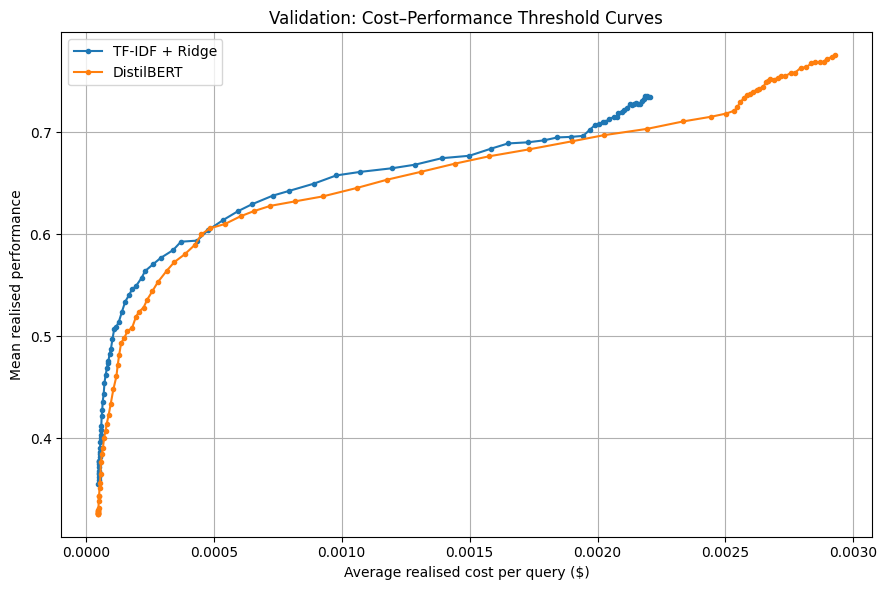

In [10]:

plt.figure(figsize=(9, 6))

plt.plot(
    tfidf_val_curve["mean_cost"],
    tfidf_val_curve["mean_performance"],
    marker=".",
    label="TF-IDF + Ridge"
)

plt.plot(
    distilbert_val_curve["mean_cost"],
    distilbert_val_curve["mean_performance"],
    marker=".",
    label="DistilBERT"
)

plt.xlabel("Average realised cost per query ($)")
plt.ylabel("Mean realised performance")
plt.title("Validation: Cost–Performance Threshold Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/validation_threshold_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


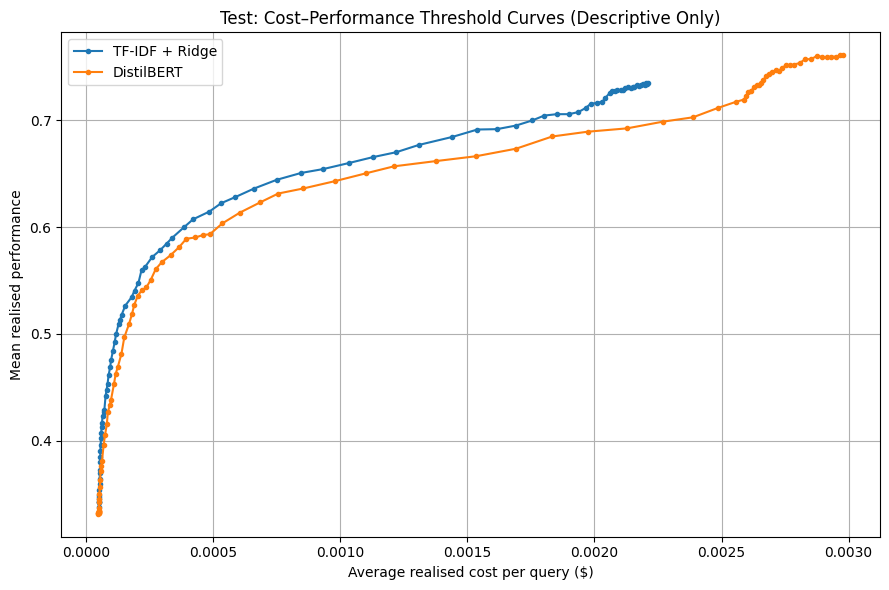

In [11]:

plt.figure(figsize=(9, 6))

plt.plot(
    tfidf_test_curve["mean_cost"],
    tfidf_test_curve["mean_performance"],
    marker=".",
    label="TF-IDF + Ridge"
)

plt.plot(
    distilbert_test_curve["mean_cost"],
    distilbert_test_curve["mean_performance"],
    marker=".",
    label="DistilBERT"
)

plt.xlabel("Average realised cost per query ($)")
plt.ylabel("Mean realised performance")
plt.title("Test: Cost–Performance Threshold Curves (Descriptive Only)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/test_threshold_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [12]:

def fit_domain_rule(X_fit, Y_fit, C_fit):
    mapping = {}

    for domain in sorted(X_fit["domain"].unique()):
        mask = X_fit["domain"].to_numpy() == domain

        mean_perf = Y_fit.loc[mask].mean().to_numpy()
        mean_cost = C_fit.loc[mask].mean().to_numpy()

        best_perf = mean_perf.max()
        candidates = np.flatnonzero(
            np.isclose(mean_perf, best_perf)
        )

        selected = candidates[
            np.argmin(mean_cost[candidates])
        ]

        mapping[domain] = int(selected)

    global_perf = Y_fit.mean().to_numpy()
    global_cost = C_fit.mean().to_numpy()

    global_best = global_perf.max()
    candidates = np.flatnonzero(
        np.isclose(global_perf, global_best)
    )
    fallback = int(
        candidates[
            np.argmin(global_cost[candidates])
        ]
    )

    return mapping, fallback


def apply_domain_rule(X_eval, mapping, fallback):
    return np.array([
        mapping.get(domain, fallback)
        for domain in X_eval["domain"]
    ], dtype=int)


# Validation: train-only fit
domain_map_train, fallback_train = fit_domain_rule(
    X_train,
    Y_train,
    C_train
)

domain_val_choices = apply_domain_rule(
    X_val,
    domain_map_train,
    fallback_train
)

domain_val_metrics = evaluate_choices(
    domain_val_choices,
    Y_val_np,
    C_val_np
)

# Test: refit on train + validation
X_trainval = pd.concat(
    [X_train, X_val],
    ignore_index=True
)
Y_trainval = pd.concat(
    [Y_train, Y_val],
    ignore_index=True
)
C_trainval = pd.concat(
    [C_train, C_val],
    ignore_index=True
)

domain_map_trainval, fallback_trainval = fit_domain_rule(
    X_trainval,
    Y_trainval,
    C_trainval
)

domain_test_choices = apply_domain_rule(
    X_test,
    domain_map_trainval,
    fallback_trainval
)

domain_test_metrics = evaluate_choices(
    domain_test_choices,
    Y_test_np,
    C_test_np
)

print("Train-only domain mapping:")
for domain, idx in domain_map_train.items():
    print(domain, "->", MODEL_COLS[idx])

print("\nTrain+validation domain mapping:")
for domain, idx in domain_map_trainval.items():
    print(domain, "->", MODEL_COLS[idx])


Train-only domain mapping:
ARC -> gpt-4-1106-preview
GSM8K -> claude-v2
MMLU -> gpt-4-1106-preview

Train+validation domain mapping:
ARC -> gpt-4-1106-preview
GSM8K -> claude-v2
MMLU -> gpt-4-1106-preview


In [13]:

argmax_val_choices = np.argmax(
    distilbert_val_pred,
    axis=1
)

argmax_test_choices = np.argmax(
    distilbert_test_pred,
    axis=1
)

argmax_val_metrics = evaluate_choices(
    argmax_val_choices,
    Y_val_np,
    C_val_np
)

argmax_test_metrics = evaluate_choices(
    argmax_test_choices,
    Y_test_np,
    C_test_np
)

print(
    "Argmax-only validation:",
    argmax_val_metrics["mean_performance"],
    argmax_val_metrics["mean_cost"]
)

print(
    "Argmax-only test:",
    argmax_test_metrics["mean_performance"],
    argmax_test_metrics["mean_cost"]
)


Argmax-only validation: 0.7754791 0.0029391388
Argmax-only test: 0.76175445 0.0029849338


In [14]:

def train_domain_classifier(X_fit):
    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )

    X_text = vectorizer.fit_transform(
        X_fit["prompt"]
    )

    clf = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

    clf.fit(
        X_text,
        X_fit["domain"]
    )

    return vectorizer, clf


def domain_classifier_choices(
    X_eval,
    vectorizer,
    classifier,
    mapping,
    fallback
):
    pred_domain = classifier.predict(
        vectorizer.transform(
            X_eval["prompt"]
        )
    )

    choices = np.array([
        mapping.get(domain, fallback)
        for domain in pred_domain
    ], dtype=int)

    return pred_domain, choices


In [15]:

# Validation classifier: train only
domain_vectorizer_train, domain_clf_train = (
    train_domain_classifier(X_train)
)

val_pred_domain, domain_clf_val_choices = (
    domain_classifier_choices(
        X_val,
        domain_vectorizer_train,
        domain_clf_train,
        domain_map_train,
        fallback_train
    )
)

domain_clf_val_metrics = evaluate_choices(
    domain_clf_val_choices,
    Y_val_np,
    C_val_np
)

val_domain_accuracy = accuracy_score(
    X_val["domain"],
    val_pred_domain
)

# Test classifier: train + validation
domain_vectorizer_trainval, domain_clf_trainval = (
    train_domain_classifier(X_trainval)
)

test_pred_domain, domain_clf_test_choices = (
    domain_classifier_choices(
        X_test,
        domain_vectorizer_trainval,
        domain_clf_trainval,
        domain_map_trainval,
        fallback_trainval
    )
)

domain_clf_test_metrics = evaluate_choices(
    domain_clf_test_choices,
    Y_test_np,
    C_test_np
)

test_domain_accuracy = accuracy_score(
    X_test["domain"],
    test_pred_domain
)

print("Domain classification accuracy:")
print("Validation:", val_domain_accuracy)
print("Test:", test_domain_accuracy)


Domain classification accuracy:
Validation: 1.0
Test: 1.0


In [16]:

frozen_val_choices = route_predictions(
    distilbert_val_pred,
    mean_train_cost,
    FINAL_THRESHOLD
)

frozen_test_choices = distilbert_test_choices

frozen_val_metrics = evaluate_choices(
    frozen_val_choices,
    Y_val_np,
    C_val_np
)

frozen_test_metrics = evaluate_choices(
    frozen_test_choices,
    Y_test_np,
    C_test_np
)

gpt4_val = {
    "mean_performance": Y_val_np[:, GPT4_INDEX].mean(),
    "mean_cost": C_val_np[:, GPT4_INDEX].mean()
}

gpt4_test = {
    "mean_performance": Y_test_np[:, GPT4_INDEX].mean(),
    "mean_cost": C_test_np[:, GPT4_INDEX].mean()
}

baseline_comparison = pd.DataFrame([
    {
        "system": "GPT-4 Fixed",
        "val_performance": gpt4_val["mean_performance"],
        "val_cost": gpt4_val["mean_cost"],
        "test_performance": gpt4_test["mean_performance"],
        "test_cost": gpt4_test["mean_cost"]
    },
    {
        "system": "Domain Rule",
        "val_performance": domain_val_metrics["mean_performance"],
        "val_cost": domain_val_metrics["mean_cost"],
        "test_performance": domain_test_metrics["mean_performance"],
        "test_cost": domain_test_metrics["mean_cost"]
    },
    {
        "system": "DistilBERT Argmax Only",
        "val_performance": argmax_val_metrics["mean_performance"],
        "val_cost": argmax_val_metrics["mean_cost"],
        "test_performance": argmax_test_metrics["mean_performance"],
        "test_cost": argmax_test_metrics["mean_cost"]
    },
    {
        "system": "Domain Classifier Router",
        "val_performance": domain_clf_val_metrics["mean_performance"],
        "val_cost": domain_clf_val_metrics["mean_cost"],
        "test_performance": domain_clf_test_metrics["mean_performance"],
        "test_cost": domain_clf_test_metrics["mean_cost"]
    },
    {
        "system": "DistilBERT Cost-Aware",
        "val_performance": frozen_val_metrics["mean_performance"],
        "val_cost": frozen_val_metrics["mean_cost"],
        "test_performance": frozen_test_metrics["mean_performance"],
        "test_cost": frozen_test_metrics["mean_cost"]
    }
])

display(baseline_comparison)


,system,val_performance,val_cost,test_performance,test_cost
0,GPT-4 Fixed,0.775044,0.003638,0.768067,0.003738
1,Domain Rule,0.776786,0.002860,0.768394,0.002917
2,DistilBERT Argmax Only,0.775479,0.002939,0.761754,0.002985
3,Domain Classifier Router,0.776786,0.002860,0.768394,0.002917
4,DistilBERT Cost-Aware,0.767639,0.002836,0.760448,0.002877


In [17]:
rows = np.arange(len(X_test))
router_perf = Y_test_np[rows, distilbert_test_choices]
router_cost = C_test_np[rows, distilbert_test_choices]
gpt4_perf = Y_test_np[:, GPT4_INDEX]
gpt4_cost = C_test_np[:, GPT4_INDEX]
B = 5000; boot = np.empty((B, 2))
for b in range(B):
    idx = rng.integers(0, len(rows), len(rows)); boot[b] = [(router_perf[idx] - gpt4_perf[idx]).mean(), 100 * (1 - router_cost[idx].mean() / gpt4_cost[idx].mean())]
ci = np.percentile(boot, [2.5, 50, 97.5], axis=0)
print(pd.DataFrame(ci, index=["2.5%", "50%", "97.5%"], columns=["perf_diff", "cost_saving_%"]))

       perf_diff  cost_saving_%
2.5%   -0.013714      21.753905
50%    -0.007727      23.055806
97.5%  -0.001524      24.361530


In [18]:
bootstrap_summary = pd.DataFrame([
    {
        "metric": "Router - GPT4 mean performance",
        "point_estimate": (router_perf - gpt4_perf).mean(),
        "ci_2.5": ci[0, 0],
        "ci_50": ci[1, 0],
        "ci_97.5": ci[2, 0]
    },
    {
        "metric": "Cost saving vs GPT4 (%)",
        "point_estimate": (1 - router_cost.mean() / gpt4_cost.mean()) * 100,
        "ci_2.5": ci[0, 1],
        "ci_50": ci[1, 1],
        "ci_97.5": ci[2, 1]
    }
])

display(bootstrap_summary)

,metric,point_estimate,ci_2.5,ci_50,ci_97.5
0,Router - GPT4 mean performance,-0.007619,-0.013714,-0.007727,-0.001524
1,Cost saving vs GPT4 (%),23.046267,21.753905,23.055806,24.361530


In [19]:

sample_indices = []

for domain in sorted(X_test["domain"].unique()):
    domain_idx = X_test.index[
        X_test["domain"] == domain
    ].to_numpy()

    chosen = rng.choice(
        domain_idx,
        size=min(10, len(domain_idx)),
        replace=False
    )

    sample_indices.extend(chosen.tolist())

sample_indices = sorted(sample_indices)

sample_rows = []

for i in sample_indices:
    selected = int(distilbert_test_choices[i])

    sample_rows.append({
        "test_index": int(i),
        "sample_id": X_test.loc[i, "sample_id"],
        "domain": X_test.loc[i, "domain"],
        "prompt": X_test.loc[i, "prompt"],
        "selected_model": MODEL_COLS[selected],
        "selected_model_index": selected,
        "predicted_scores_json": json.dumps(
            distilbert_test_pred[i].astype(float).tolist()
        ),
        "actual_performance_json": json.dumps(
            Y_test_np[i].astype(float).tolist()
        ),
        "actual_cost_json": json.dumps(
            C_test_np[i].astype(float).tolist()
        )
    })

benchmark_sample = pd.DataFrame(sample_rows)

display(
    benchmark_sample[
        [
            "test_index",
            "domain",
            "selected_model"
        ]
    ]
)

benchmark_sample.to_csv(
    "/content/drive/MyDrive/benchmark_replay_sample.csv",
    index=False
)

print(
    "Saved:",
    "/content/drive/MyDrive/benchmark_replay_sample.csv"
)


,test_index,domain,selected_model
0,22,GSM8K,claude-v2
1,172,ARC,gpt-4-1106-preview
2,221,ARC,gpt-4-1106-preview
3,257,ARC,gpt-4-1106-preview
4,543,GSM8K,claude-v2
5,589,GSM8K,claude-v2
6,746,MMLU,mistralai/mixtral-8x7b-chat
7,964,ARC,gpt-4-1106-preview
8,1094,GSM8K,claude-v2
9,1109,ARC,gpt-4-1106-preview


Saved: /content/drive/MyDrive/benchmark_replay_sample.csv


In [20]:

tfidf_val_curve.to_csv(
    "/content/drive/MyDrive/tfidf_extended_val_curve.csv",
    index=False
)

tfidf_test_curve.to_csv(
    "/content/drive/MyDrive/tfidf_extended_test_curve.csv",
    index=False
)

distilbert_val_curve.to_csv(
    "/content/drive/MyDrive/distilbert_val_curve_010_100.csv",
    index=False
)

distilbert_test_curve.to_csv(
    "/content/drive/MyDrive/distilbert_test_curve_010_100.csv",
    index=False
)

baseline_comparison.to_csv(
    "/content/drive/MyDrive/extended_baseline_comparison.csv",
    index=False
)

bootstrap_summary.to_csv(
    "/content/drive/MyDrive/paired_bootstrap_summary.csv",
    index=False
)

print("All robustness outputs saved to Google Drive.")


All robustness outputs saved to Google Drive.


In [21]:

from importlib.metadata import version, PackageNotFoundError

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "torch",
    "transformers",
    "datasets",
    "accelerate",
    "gradio",
    "huggingface-hub",
    "joblib",
    "matplotlib"
]

locked = []

for package in packages:
    try:
        locked.append(
            f"{package}=={version(package)}"
        )
    except PackageNotFoundError:
        print("Not installed:", package)

requirements_lock = "\n".join(locked) + "\n"

print(requirements_lock)

with open(
    "/content/drive/MyDrive/requirements_locked.txt",
    "w"
) as f:
    f.write(requirements_lock)

print(
    "Saved:",
    "/content/drive/MyDrive/requirements_locked.txt"
)


numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
torch==2.11.0+cpu
transformers==5.17.0
datasets==4.8.5
accelerate==1.15.0
gradio==6.27.0
huggingface-hub==1.31.0
joblib==1.6.0
matplotlib==3.10.0

Saved: /content/drive/MyDrive/requirements_locked.txt


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        X_test["domain"],
        test_pred_domain
    )
)

print("\nConfusion matrix:")

display(
    pd.crosstab(
        X_test["domain"],
        test_pred_domain,
        rownames=["True"],
        colnames=["Predicted"]
    )
)

print("\nLiteral domain-name checks:")

for word in [
    "MMLU",
    "ARC",
    "GSM8K",
    "grade-school-math"
]:
    rate = (
        X_test["prompt"]
        .str.contains(
            word,
            case=False,
            regex=False
        )
        .mean()
    )

    print(
        word,
        round(rate * 100, 2),
        "%"
    )

              precision    recall  f1-score   support

         ARC       1.00      1.00      1.00       147
       GSM8K       1.00      1.00      1.00       745
        MMLU       1.00      1.00      1.00      1405

    accuracy                           1.00      2297
   macro avg       1.00      1.00      1.00      2297
weighted avg       1.00      1.00      1.00      2297


Confusion matrix:


Predicted,ARC,GSM8K,MMLU
True,,,
ARC,147,0,0
GSM8K,0,745,0
MMLU,0,0,1405



Literal domain-name checks:
MMLU 0.0 %
ARC 3.92 %
GSM8K 0.0 %
grade-school-math 0.0 %


In [23]:
# Convert router-GPT4 differences into
# GPT4-router performance gaps in percentage points.

bootstrap_gap_pp = (
    -boot[:, 0] * 100
)

print(
    "Observed gap:",
    (
        gpt4_perf.mean()
        - router_perf.mean()
    ) * 100,
    "percentage points"
)

print(
    "\nBootstrap gap 95% CI:"
)

print(
    np.percentile(
        bootstrap_gap_pp,
        [2.5, 50, 97.5]
    )
)

print(
    "\nProbability bootstrap gap <= 1 pp:"
)

print(
    np.mean(
        bootstrap_gap_pp <= 1.0
    )
)

print(
    "\nOne-sided 95% upper gap:"
)

print(
    np.percentile(
        bootstrap_gap_pp,
        95
    )
)

Observed gap: 0.76186657 percentage points

Bootstrap gap 95% CI:
[0.15237266 0.77274707 1.37135396]

Probability bootstrap gap <= 1 pp:
0.773

One-sided 95% upper gap:
1.2734000571072102


In [24]:
import re

checks = [
    r"\bMMLU\b",
    r"\bARC\b",
    r"\bGSM8K\b",
    r"\bgrade-school-math\b"
]

for pattern in checks:

    rate = (
        X_test["prompt"]
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
        .mean()
    )

    print(
        pattern,
        round(rate * 100, 2),
        "%"
    )

\bMMLU\b 0.0 %
\bARC\b 0.0 %
\bGSM8K\b 0.0 %
\bgrade-school-math\b 0.0 %
